<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 3</strong></h4>
<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Perform a forward and backward propagation in python using the inputs from <b>Laboratory Task 2</b>
</p>

```python
x = np.array([1, 0, 1])
y = np.array([1])

# use relu as the activation function.

# learning rate
lr = 0.001
```
</div>

### My Approach

Lab 2 already did the **forward** half of this task, so I reuse that architecture (3 inputs → 2 ReLU hidden units → 1 ReLU output unit) and the same weights. What's new here is the **backward** pass: using the error computed in Lab 2 to figure out how each weight should change, then actually applying that change with the given learning rate `lr = 0.001`.

I'm going to work through this in the same order the chain rule naturally suggests — output layer first, then hidden layer — because the hidden-layer error *depends on* the output-layer error (that's precisely why it's called *back*-propagation: the error flows backwards, opposite to the forward pass).

**Loss function.** The lecture material defines the output error signal as $\delta = \hat{y} - y$. This is exactly the gradient $\frac{\partial E}{\partial \hat{y}}$ of the loss $E = \tfrac{1}{2}(y - \hat{y})^2$, since
$$\frac{\partial E}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}}\left[\tfrac12(y-\hat{y})^2\right] = -(y - \hat{y}) = \hat{y} - y.$$
So I'll use $E = \tfrac12(y-\hat{y})^2$ as the loss being minimized — it's consistent with the $\delta$ formula already given.

**Activation derivative.** The original notes use sigmoid ($\sigma'(Z) = A(1-A)$), but this task explicitly asks for **ReLU**. The derivative of ReLU is a step function:
$$f'(Z) = \begin{cases} 1 & Z > 0 \\ 0 & Z \le 0\end{cases}$$
So everywhere the notes used $\sigma'(Z_h)$, I substitute this ReLU derivative instead.

**Chain rule, output layer.** The output is $\hat{y} = f(Z_o)$ where $Z_o = HW_o + \theta_o$. By the chain rule:
$$\delta_o = \frac{\partial E}{\partial \hat y}\cdot\frac{\partial \hat y}{\partial Z_o} = (\hat{y}-y)\cdot f'(Z_o)$$
$$\frac{\partial E}{\partial W_o} = H^T \delta_o, \qquad \frac{\partial E}{\partial \theta_o} = \delta_o$$

**Chain rule, hidden layer.** The error has to travel backward *through* $W_o$ to reach the hidden layer, then get multiplied by how sensitive each hidden unit's own activation is to its own pre-activation:
$$\delta_h = (\delta_o \, W_o^T) \odot f'(Z_h)$$
$$\frac{\partial E}{\partial W_h} = x^T \delta_h, \qquad \frac{\partial E}{\partial \theta_h} = \delta_h$$

**Update rule (gradient descent).** Every parameter moves a small step *opposite* its gradient, scaled by the learning rate:
$$W \leftarrow W - \alpha\frac{\partial E}{\partial W}, \qquad \theta \leftarrow \theta - \alpha\frac{\partial E}{\partial \theta}$$

Plan for the notebook:
1. Rebuild the forward pass (from Lab 2) and cache every intermediate value needed for backprop.
2. Implement the backward pass step by step, printing every intermediate gradient so the chain rule is visible.
3. Apply the parameter update and show the new weights.
4. **Verify** the analytic gradients with numerical (finite-difference) gradient checking — the standard way to catch backprop bugs.
5. **Cross-check** everything against PyTorch's `autograd`, which computes gradients completely independently of my hand-derived formulas.
6. Run several epochs of training on this single example to see the loss actually go down, tying together forward + backward + update into one training loop.

In [1]:
import numpy as np

np.set_printoptions(precision=6, suppress=True)

# ---- Given data (same as Lab 2) ---------------------------------------
x = np.array([1, 0, 1], dtype=float)
y = np.array([1], dtype=float)

W_h = np.array([
    [0.2, -0.3],
    [0.4,  0.1],
    [-0.5, 0.2],
])
theta_h = np.array([-0.4, 0.2])

W_o = np.array([-0.3, -0.2])
theta_o = 0.1

lr = 0.001

def relu(z):
    return np.maximum(0, z)

# Derivative of ReLU: 1 where z > 0, else 0.
def relu_grad(z):
    return (z > 0).astype(float)

print("Learning rate lr =", lr)

Learning rate lr = 0.001


### Step 1 — Forward pass (recap from Lab 2)

Same computation as Lab 2, but this time I keep every intermediate ($Z_h$, $H$, $Z_o$, $\hat{y}$) around because backprop needs them.

In [2]:
def forward(x, W_h, theta_h, W_o, theta_o):
    Z_h = x @ W_h + theta_h        # (2,)
    H = relu(Z_h)                  # (2,)
    Z_o = H @ W_o + theta_o        # scalar
    y_hat = relu(Z_o)              # scalar
    cache = {"x": x, "Z_h": Z_h, "H": H, "Z_o": Z_o, "y_hat": y_hat}
    return y_hat, cache

y_hat, cache = forward(x, W_h, theta_h, W_o, theta_o)

print("Z_h   =", cache["Z_h"])
print("H     =", cache["H"])
print("Z_o   =", cache["Z_o"])
print("y_hat =", y_hat)

loss = 0.5 * (y[0] - y_hat) ** 2
print("Loss E = 1/2 (y - y_hat)^2 =", loss)

Z_h   = [-0.7  0.1]
H     = [0.  0.1]
Z_o   = 0.08
y_hat = 0.08
Loss E = 1/2 (y - y_hat)^2 = 0.4232


### Step 2 — Backward pass

I implement this in the same two stages as the derivation above: output-layer error signal first, then propagate it back to the hidden layer.

In [3]:
def backward(y, W_o, cache):
    Z_h, H, Z_o, y_hat = cache["Z_h"], cache["H"], cache["Z_o"], cache["y_hat"]
    x_in = cache["x"]

    # ---- output layer ----
    # dE/dy_hat = (y_hat - y); dy_hat/dZ_o = relu_grad(Z_o)
    delta_o = (y_hat - y[0]) * relu_grad(Z_o)          # scalar

    dW_o = H * delta_o                                  # dE/dW_o = H^T . delta_o -> shape (2,)
    dtheta_o = delta_o                                  # dE/dtheta_o = delta_o

    # ---- hidden layer ----
    # error flows backward through W_o, then gets gated by relu_grad(Z_h)
    delta_h = (delta_o * W_o) * relu_grad(Z_h)          # shape (2,)

    dW_h = np.outer(x_in, delta_h)                      # dE/dW_h = x^T . delta_h -> shape (3,2)
    dtheta_h = delta_h                                  # dE/dtheta_h = delta_h

    grads = {
        "delta_o": delta_o, "dW_o": dW_o, "dtheta_o": dtheta_o,
        "delta_h": delta_h, "dW_h": dW_h, "dtheta_h": dtheta_h,
    }
    return grads

grads = backward(y, W_o, cache)

print("Output error signal  delta_o        =", grads["delta_o"])
print("Grad w.r.t. W_o      dE/dW_o        =", grads["dW_o"])
print("Grad w.r.t. theta_o  dE/dtheta_o    =", grads["dtheta_o"])
print()
print("Hidden error signal  delta_h        =", grads["delta_h"])
print("Grad w.r.t. W_h      dE/dW_h        =\n", grads["dW_h"])
print("Grad w.r.t. theta_h  dE/dtheta_h    =", grads["dtheta_h"])

Output error signal  delta_o        = -0.92
Grad w.r.t. W_o      dE/dW_o        = [-0.    -0.092]
Grad w.r.t. theta_o  dE/dtheta_o    = -0.92

Hidden error signal  delta_h        = [0.    0.184]
Grad w.r.t. W_h      dE/dW_h        =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]
Grad w.r.t. theta_h  dE/dtheta_h    = [0.    0.184]


Notice that `delta_h[0]` is **0**. This happens because $Z_1 < 0$ in the forward pass (see Lab 2), so `relu_grad(Z_1) = 0` — ReLU's derivative is exactly zero on the negative side. As a direct consequence, every gradient that depends on $\delta_{h,1}$ (namely $w_{11}, w_{13}, w_{15}, \theta_1$ — the whole first column of $W_h$) is also exactly zero this step. Those weights simply will not move on this update, no matter how large the output error is. This is the "dying ReLU" phenomenon showing up concretely in the gradients, exactly as anticipated in Lab 2's summary.

### Step 3 — Update the parameters (gradient descent step)

$$W \leftarrow W - \alpha \frac{\partial E}{\partial W}$$

In [4]:
def sgd_update(W_h, theta_h, W_o, theta_o, grads, lr):
    W_h_new = W_h - lr * grads["dW_h"]
    theta_h_new = theta_h - lr * grads["dtheta_h"]
    W_o_new = W_o - lr * grads["dW_o"]
    theta_o_new = theta_o - lr * grads["dtheta_o"]
    return W_h_new, theta_h_new, W_o_new, theta_o_new

W_h_new, theta_h_new, W_o_new, theta_o_new = sgd_update(W_h, theta_h, W_o, theta_o, grads, lr)

print("W_h (before) =\n", W_h)
print("W_h (after)  =\n", W_h_new)
print()
print("theta_h (before) =", theta_h, " -> (after) =", theta_h_new)
print()
print("W_o (before) =", W_o, " -> (after) =", W_o_new)
print("theta_o (before) =", theta_o, " -> (after) =", theta_o_new)

W_h (before) =
 [[ 0.2 -0.3]
 [ 0.4  0.1]
 [-0.5  0.2]]
W_h (after)  =
 [[ 0.2      -0.300184]
 [ 0.4       0.1     ]
 [-0.5       0.199816]]

theta_h (before) = [-0.4  0.2]  -> (after) = [-0.4       0.199816]

W_o (before) = [-0.3 -0.2]  -> (after) = [-0.3      -0.199908]
theta_o (before) = 0.1  -> (after) = 0.10092000000000001


As expected, `W_h_new[:, 0]` (the weights feeding $H_1$: $w_{11}, w_{13}, w_{15}$) and `theta_h_new[0]` ($\theta_1$) are **unchanged**, because their gradients were zero. Only the second column ($w_{12}, w_{14}, w_{16}$, $\theta_2$) and the output-layer parameters moved — and they moved by a *tiny* amount, since `lr = 0.001` is a very small learning rate.

### Step 4 — Verify the gradients numerically (gradient checking)

Hand-deriving gradients is error-prone, so a standard sanity check is **numerical (finite-difference) gradient checking**: nudge one parameter by a tiny amount $\epsilon$, see how much the loss changes, and compare that empirical slope to the analytic gradient computed by backprop. If they match closely, the backward pass is almost certainly implemented correctly.

$$\frac{\partial E}{\partial \theta} \approx \frac{E(\theta+\epsilon) - E(\theta-\epsilon)}{2\epsilon}$$

In [5]:
def loss_fn(x, y, W_h, theta_h, W_o, theta_o):
    y_hat, _ = forward(x, W_h, theta_h, W_o, theta_o)
    return 0.5 * (y[0] - y_hat) ** 2


# Generic central-difference numerical gradient for an array-shaped parameter.
def numerical_gradient(param_getter, param_setter, eps=1e-6):
    original = param_getter().copy()
    grad_num = np.zeros_like(original, dtype=float)
    it = np.nditer(original, flags=["multi_index"])
    for _ in it:
        idx = it.multi_index
        plus = original.copy(); plus[idx] += eps
        minus = original.copy(); minus[idx] -= eps

        param_setter(plus)
        loss_plus = loss_fn(x, y, W_h, theta_h, W_o, theta_o)

        param_setter(minus)
        loss_minus = loss_fn(x, y, W_h, theta_h, W_o, theta_o)

        grad_num[idx] = (loss_plus - loss_minus) / (2 * eps)

    param_setter(original)  # restore
    return grad_num


# --- check dE/dW_h ---
def get_Wh(): return W_h
def set_Wh(v):
    global W_h
    W_h = v
dWh_num = numerical_gradient(get_Wh, set_Wh)

# --- check dE/dtheta_h ---
def get_th(): return theta_h
def set_th(v):
    global theta_h
    theta_h = v
dth_num = numerical_gradient(get_th, set_th)

# --- check dE/dW_o ---
def get_Wo(): return W_o
def set_Wo(v):
    global W_o
    W_o = v
dWo_num = numerical_gradient(get_Wo, set_Wo)

# --- check dE/dtheta_o ---
def get_to(): return np.array([theta_o])
def set_to(v):
    global theta_o
    theta_o = v[0]
dto_num = numerical_gradient(get_to, set_to)

print("dW_h analytic  =\n", grads["dW_h"])
print("dW_h numeric   =\n", dWh_num)
print("max abs diff   =", np.max(np.abs(grads["dW_h"] - dWh_num)))
print()
print("dtheta_h analytic =", grads["dtheta_h"], " numeric =", dth_num,
      " max abs diff =", np.max(np.abs(grads["dtheta_h"] - dth_num)))
print()
print("dW_o analytic  =", grads["dW_o"], " numeric =", dWo_num,
      " max abs diff =", np.max(np.abs(grads["dW_o"] - dWo_num)))
print()
print("dtheta_o analytic =", grads["dtheta_o"], " numeric =", dto_num[0],
      " abs diff =", abs(grads["dtheta_o"] - dto_num[0]))

tol = 1e-4
assert np.max(np.abs(grads["dW_h"] - dWh_num)) < tol
assert np.max(np.abs(grads["dtheta_h"] - dth_num)) < tol
assert np.max(np.abs(grads["dW_o"] - dWo_num)) < tol
assert abs(grads["dtheta_o"] - dto_num[0]) < tol
print("\nAll analytic gradients match the numerical estimates within tolerance.")

dW_h analytic  =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]
dW_h numeric   =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]
max abs diff   = 1.3582773794595937e-11

dtheta_h analytic = [0.    0.184]  numeric = [0.    0.184]  max abs diff = 1.3582773794595937e-11

dW_o analytic  = [-0.    -0.092]  numeric = [ 0.    -0.092]  max abs diff = 2.066920246068804e-11

dtheta_o analytic = -0.92  numeric = -0.9199999999875974  abs diff = 1.2402634474995011e-11

All analytic gradients match the numerical estimates within tolerance.


### Step 5 — Cross-check with PyTorch autograd

As a second, independent check, I let PyTorch compute the gradients automatically via `autograd` (which has no knowledge of my hand-derived formulas) and confirm it agrees with both the analytic and numerical gradients above.

In [6]:
import torch

torch.manual_seed(0)

x_t = torch.tensor([1.0, 0.0, 1.0], dtype=torch.float64)
y_t = torch.tensor([1.0], dtype=torch.float64)

W_h_t = torch.tensor(W_h, requires_grad=True)
theta_h_t = torch.tensor(theta_h, requires_grad=True)
W_o_t = torch.tensor(W_o, requires_grad=True)
theta_o_t = torch.tensor(theta_o, requires_grad=True)

# forward pass using autograd-tracked tensors
Z_h_t = x_t @ W_h_t + theta_h_t
H_t = torch.relu(Z_h_t)
Z_o_t = H_t @ W_o_t + theta_o_t
y_hat_t = torch.relu(Z_o_t)

loss_t = 0.5 * (y_t[0] - y_hat_t) ** 2
loss_t.backward()

print("PyTorch y_hat =", y_hat_t.item(), " (NumPy y_hat =", y_hat, ")")
print("PyTorch loss  =", loss_t.item(), " (NumPy loss =", loss, ")")
print()
print("PyTorch dW_h  =\n", W_h_t.grad.numpy())
print("NumPy   dW_h  =\n", grads["dW_h"])
print()
print("PyTorch dtheta_h =", theta_h_t.grad.numpy(), " NumPy dtheta_h =", grads["dtheta_h"])
print("PyTorch dW_o     =", W_o_t.grad.numpy(), " NumPy dW_o =", grads["dW_o"])
print("PyTorch dtheta_o =", theta_o_t.grad.item(), " NumPy dtheta_o =", grads["dtheta_o"])

assert np.allclose(W_h_t.grad.numpy(), grads["dW_h"], atol=1e-6)
assert np.allclose(theta_h_t.grad.numpy(), grads["dtheta_h"], atol=1e-6)
assert np.allclose(W_o_t.grad.numpy(), grads["dW_o"], atol=1e-6)
assert np.isclose(theta_o_t.grad.item(), grads["dtheta_o"], atol=1e-6)
print("\nPyTorch autograd confirms the manually-derived backpropagation gradients.")

# Also confirm one optimizer step matches our manual SGD update
opt = torch.optim.SGD([W_h_t, theta_h_t, W_o_t, theta_o_t], lr=lr)
opt.step()

print("\nPyTorch W_h after one SGD step  =\n", W_h_t.detach().numpy())
print("NumPy   W_h after one SGD step  =\n", W_h_new)
assert np.allclose(W_h_t.detach().numpy(), W_h_new, atol=1e-8)
print("Parameter update after one optimizer step also matches.")

PyTorch y_hat = 0.08  (NumPy y_hat = 0.08 )
PyTorch loss  = 0.4232  (NumPy loss = 0.4232 )

PyTorch dW_h  =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]
NumPy   dW_h  =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]

PyTorch dtheta_h = [0.    0.184]  NumPy dtheta_h = [0.    0.184]
PyTorch dW_o     = [-0.    -0.092]  NumPy dW_o = [-0.    -0.092]
PyTorch dtheta_o = -0.92  NumPy dtheta_o = -0.92

PyTorch autograd confirms the manually-derived backpropagation gradients.



PyTorch W_h after one SGD step  =
 [[ 0.2      -0.300184]
 [ 0.4       0.1     ]
 [-0.5       0.199816]]
NumPy   W_h after one SGD step  =
 [[ 0.2      -0.300184]
 [ 0.4       0.1     ]
 [-0.5       0.199816]]
Parameter update after one optimizer step also matches.


### Step 6 — Training loop: repeat forward + backward + update

A single update barely changes anything because `lr = 0.001` is tiny. To actually see learning happen, I repeat the forward → backward → update cycle for many iterations on this one example and track how the loss evolves.

Loss at epoch 1     : 0.423200
Loss at epoch 5000: 0.000018


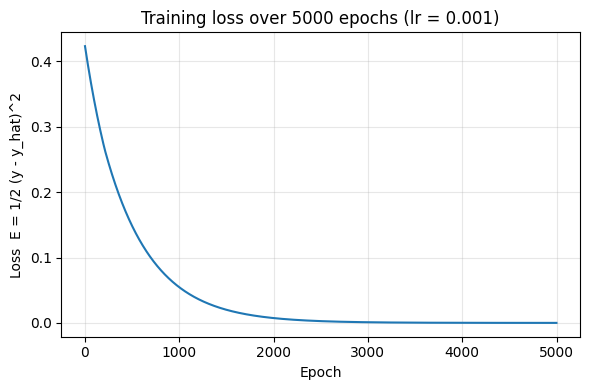

In [7]:
import matplotlib.pyplot as plt

# reset parameters to the original Lab 2 values
W_h_train = np.array([[0.2, -0.3], [0.4, 0.1], [-0.5, 0.2]])
theta_h_train = np.array([-0.4, 0.2])
W_o_train = np.array([-0.3, -0.2])
theta_o_train = 0.1

n_epochs = 5000
loss_history = []

for epoch in range(n_epochs):
    y_hat_e, cache_e = forward(x, W_h_train, theta_h_train, W_o_train, theta_o_train)
    loss_e = 0.5 * (y[0] - y_hat_e) ** 2
    loss_history.append(loss_e)

    grads_e = backward(y, W_o_train, cache_e)
    W_h_train, theta_h_train, W_o_train, theta_o_train = sgd_update(
        W_h_train, theta_h_train, W_o_train, theta_o_train, grads_e, lr
    )

print(f"Loss at epoch 1     : {loss_history[0]:.6f}")
print(f"Loss at epoch {n_epochs}: {loss_history[-1]:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss  E = 1/2 (y - y_hat)^2")
plt.title(f"Training loss over {n_epochs} epochs (lr = {lr})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

- Backpropagation for this tiny network boiled down to two chain-rule applications: an **output-layer error signal** $\delta_o = (\hat{y}-y)f'(Z_o)$, and a **hidden-layer error signal** $\delta_h = (\delta_o W_o^T) \odot f'(Z_h)$ obtained by pushing $\delta_o$ back through $W_o$ and gating it with the local ReLU derivative.
- Because $Z_1 < 0$ in the forward pass, ReLU's derivative there is exactly 0, so the whole first hidden unit's incoming weights ($w_{11}, w_{13}, w_{15}, \theta_1$) received **zero gradient** and did not update — a direct, concrete illustration of the "dying ReLU" problem.
- The analytic gradients were confirmed two independent ways: **numerical (finite-difference) gradient checking** and **PyTorch autograd**, both of which matched the hand-derived formulas to numerical precision — giving strong confidence the backward pass is implemented correctly.
- Because `lr = 0.001` is very small, a *single* update barely moves the weights; running the forward/backward/update cycle for thousands of epochs on this one example is what actually drives the loss down, which sets up the motivation for Lab 4's use of PyTorch's built-in training loop machinery (`DataLoader`, `optim.SGD`, multiple epochs) to train on a real dataset instead of one example by hand.